## 4.4 拉丁超立方设计

我们需要处理的影响因素或许有成百上千个，但真正对输出结果起到关键作用的因素可能仅有少数几个。著名的帕累托原理指出，系统中 20% 的影响因素，便能解释输出结果 80% 的变异情况。在试验设计相关文献中，该规律被称作效应稀疏原理（吴与滨田，2021，第 169 页）。这种普遍存在的现象会对试验设计产生怎样的影响？

考虑一个包含两个因子、4 次试验的试验设计，极大极小设计与极小极大设计如图 4.6 所示。本例中基于聚类的设计和极小极大设计完全一致。现假设因子 $x_2$ 无关紧要，即其对输出结果的影响可以忽略不计。那么对于左侧的设计而言，相当于在 $x_1=0$ 和 $x_1=1$ 两处各开展了两次试验；对于右侧设计，则是在 $x_1=0.25$ 和 $x_1=0.75$ 两处各重复两次试验。由于输出不存在误差，试验得到的输出数值将会完全相同。这一点在开展试验前就能预判，也就是说，重复开展这两组试验纯属浪费时间。倘若 $x_1$ 无影响、仅有 $x_2$ 起作用，也会出现相同的问题。这类不理想的情形在实际应用中极易出现，我们该如何规避？

> **图 4.6** 四轮试验下的极大极小与极小极大设计，及其在各坐标轴上的投影。

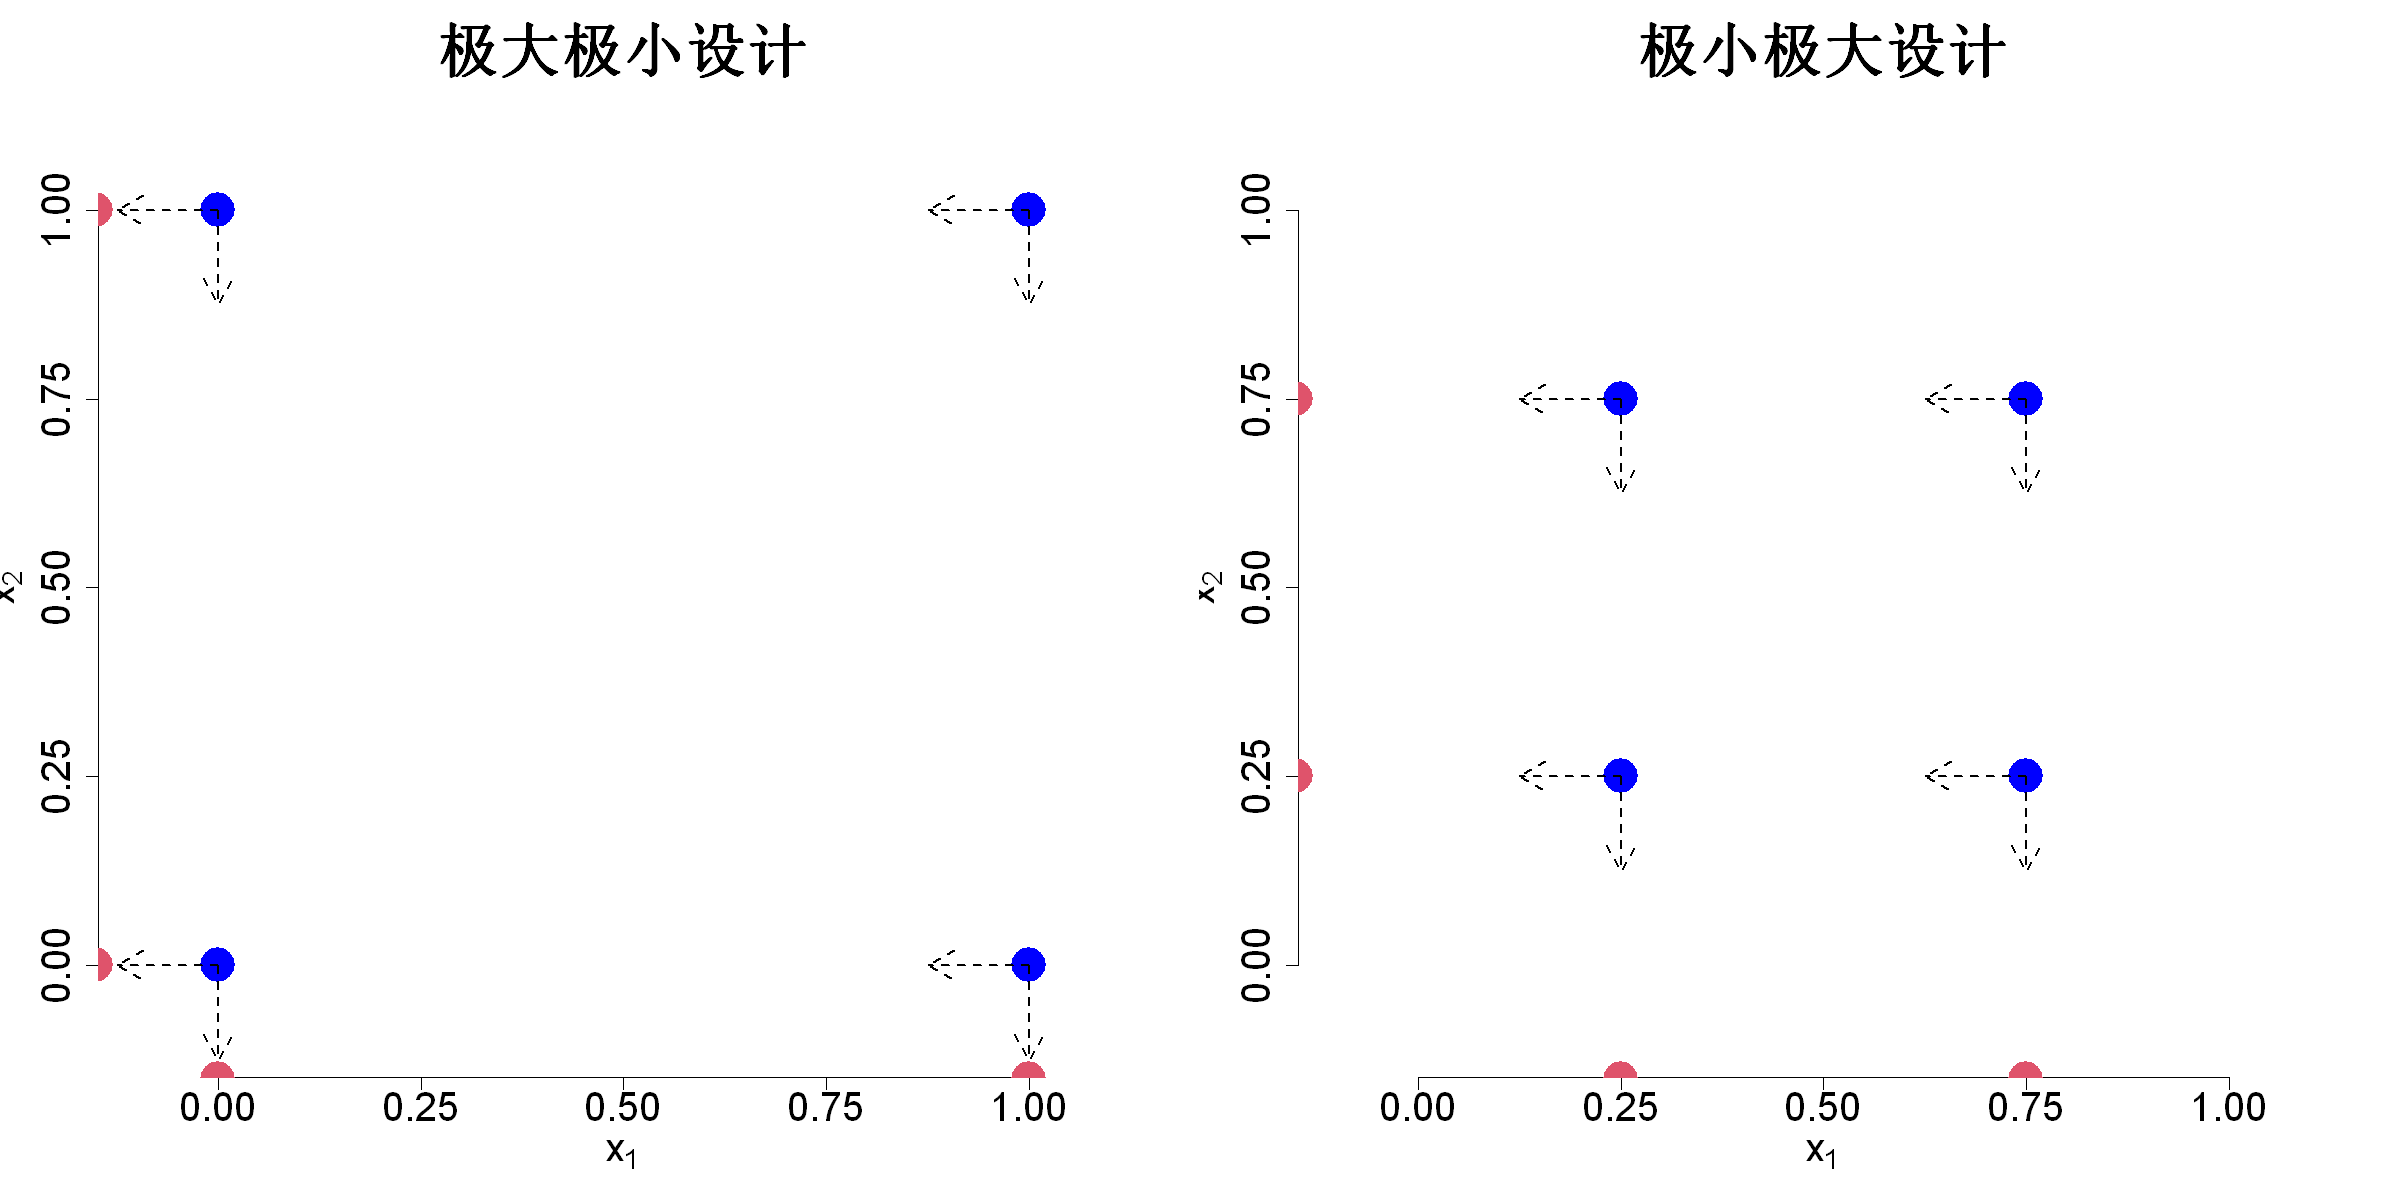

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.6-D.csv")){
  D1=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE) # 4x2
  D2=matrix(c(0.25,0.25,.25,.75,.75,.25,.75,.75),nrow=4,ncol=2,byrow=TRUE) # 4x2
  write.csv(data.frame(D1=D1,D2=D2),"data/4.6-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.6-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极大极小设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D1[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D1[,2]),col=2,pch=16,cex=4)
arrows(0,0,0,-.125,lwd=2,lty=2)
arrows(1,0,1,-.125,lwd=2,lty=2)
arrows(0,1,0,.875,lwd=2,lty=2)
arrows(1,1,1,.875,lwd=2,lty=2)
arrows(0,0,-.125,0,lwd=2,lty=2)
arrows(0,1,-.125,1,lwd=2,lty=2)
arrows(1,0,.875,0,lwd=2,lty=2)
arrows(1,1,.875,1,lwd=2,lty=2)
plot(D2,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极小极大设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D2[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D2[,2]),col=2,pch=16,cex=4)
arrows(.25,.25,.25,.125,lwd=2,lty=2)
arrows(.75,.25,.75,.125,lwd=2,lty=2)
arrows(.25,.75,.25,.625,lwd=2,lty=2)
arrows(.75,.75,.75,.625,lwd=2,lty=2)
arrows(.25,.25,.125,.25,lwd=2,lty=2)
arrows(.25,.75,.125,.75,lwd=2,lty=2)
arrows(.75,.25,.625,.25,lwd=2,lty=2)
arrows(.75,.75,.625,.75,lwd=2,lty=2)

倘若我们事先知晓变量 $x_2$ 无关紧要，就应当针对变量 $x_1$ 采用最优试验设计开展四次试验；反之同理。图 4.7 左侧子图展示了这类设计方案，此处针对每个输入变量采用极小极大设计：$\{(i - 0.5)/4\}_{i=1}^4$。可以发现，将四个试验设计点分别投影至两条坐标轴上时，两个因子各自都会得到四个互不相同的数值。因此，即便试验结束后发现其中某一个因子并无显著影响，该设计方案依旧能够拥有良好的试验效果。

> **图 4.7** 4 次采样的拉丁超立方设计，其投影分别展示在各坐标轴上。

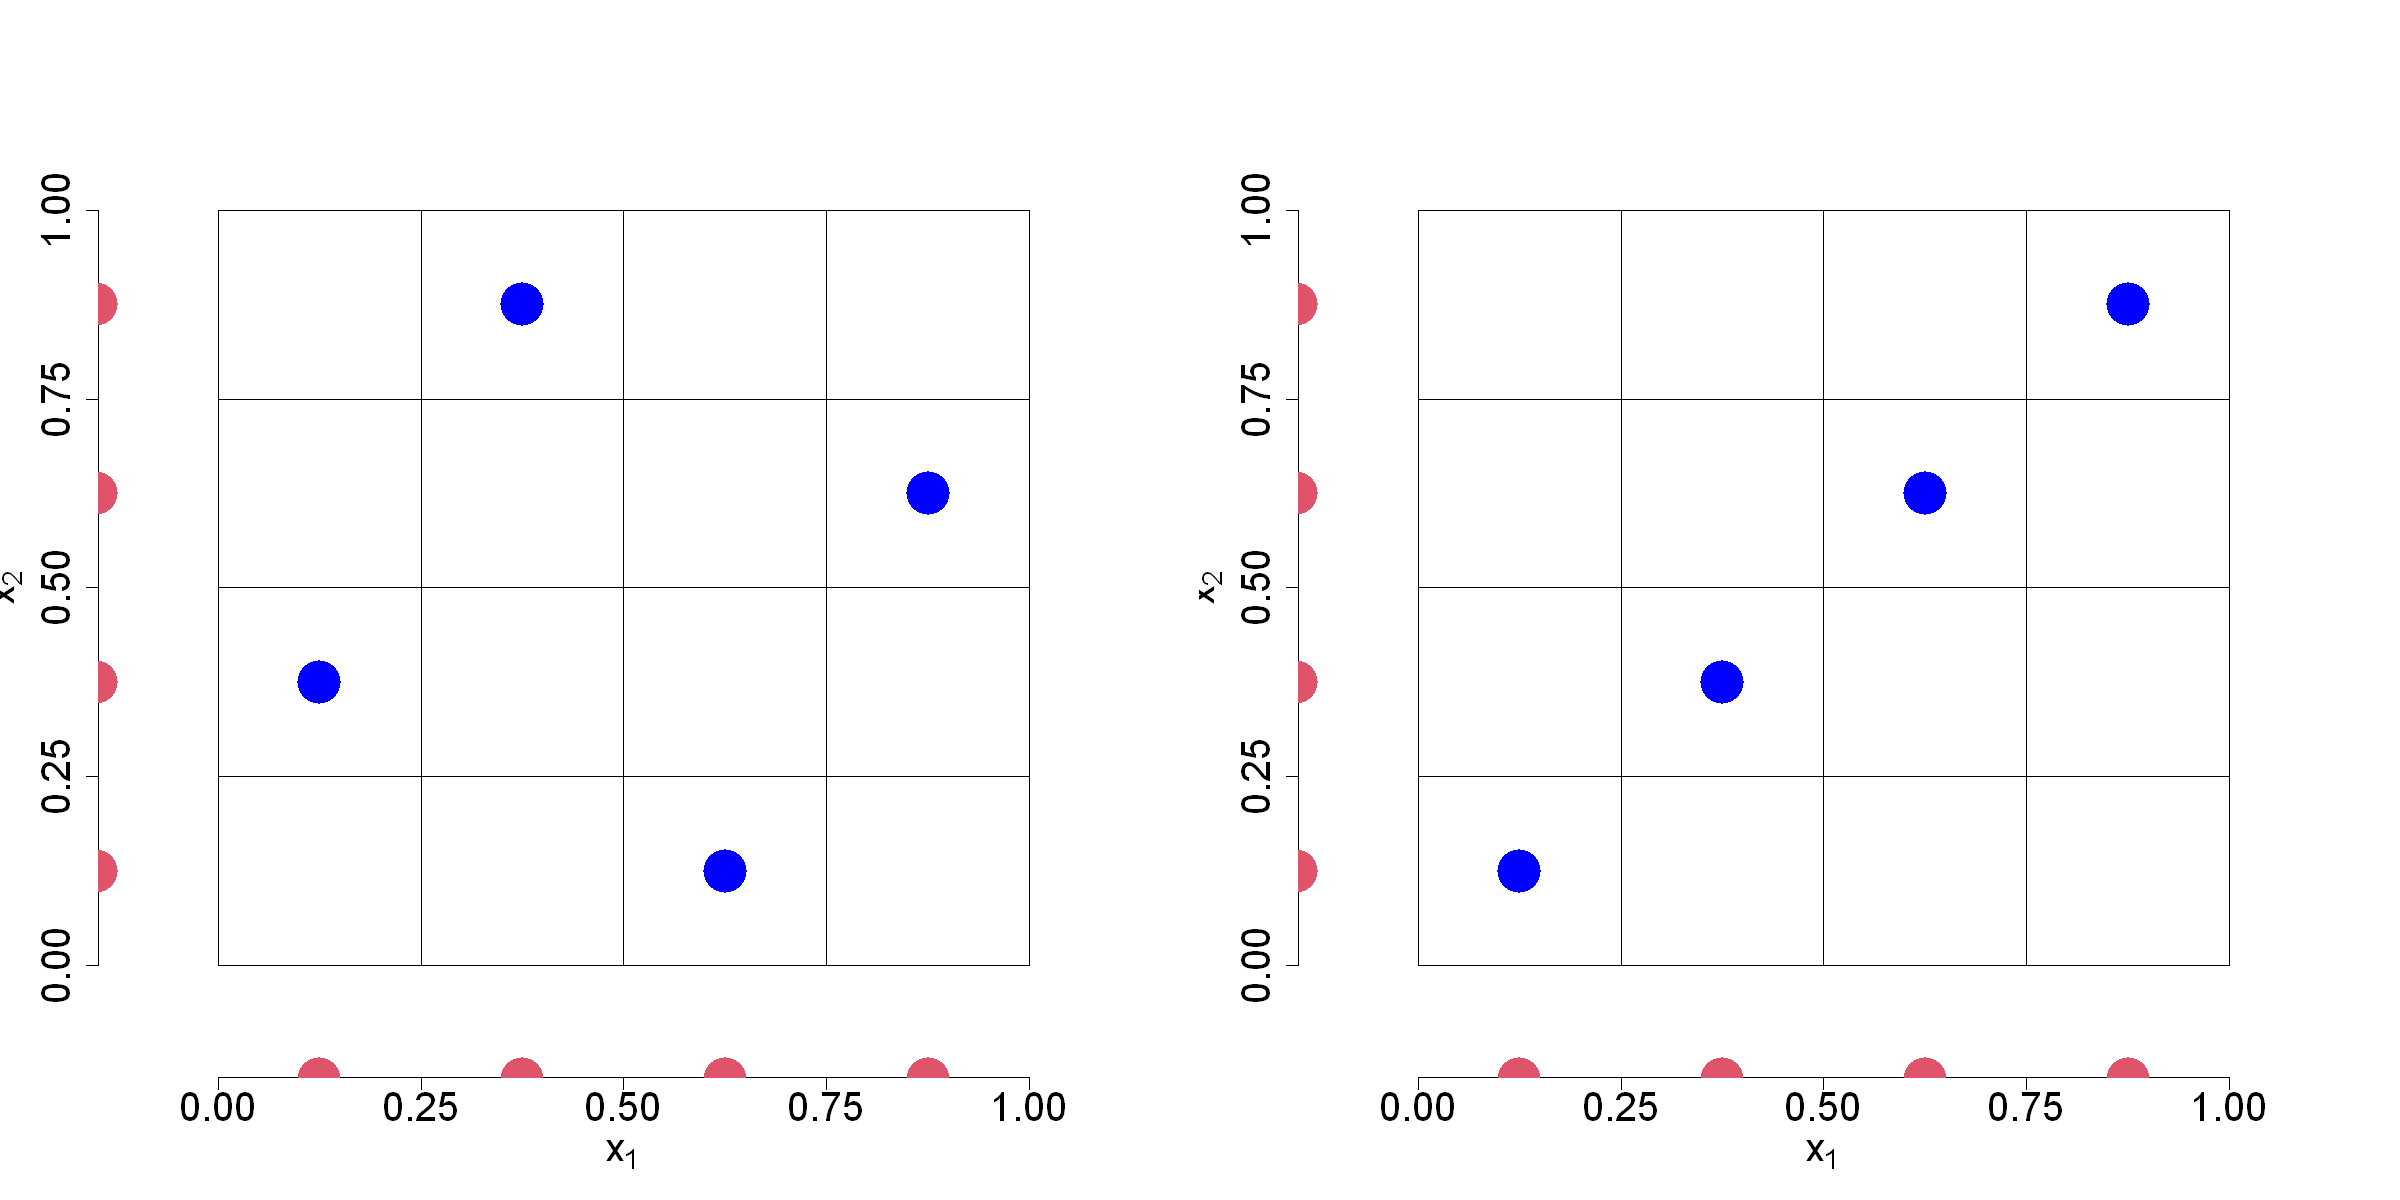

In [2]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/4.7-D.csv"))||(!file.exists("data/4.7-para.csv"))){
  p=2;n=4
  set.seed(1)
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 4x2
  D2=(cbind(1:n,1:n)-.5)/n # 4x2
  write.csv(data.frame(D1=D1,D2=D2),file="data/4.7-D.csv",row.names=FALSE)
  write.csv(data.frame(n=n),file="data/4.7-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.7-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.7-para.csv")
n=para$n

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D1[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D1[,2]),col=2,pch=16,cex=5)
plot(D2,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D2[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D2[,2]),col=2,pch=16,cex=5)

构造具备优良一维投影特性的试验设计十分简便。将每一条坐标轴均划分为 $n$ 个等间距区间。随后，只需保证每行、每列仅存在一个样本点，即可得到所需投影效果，具体形式见图 4.7。拓展至高维情形时，可通过下式实现：

$$
\left\{\frac{\pi_j(i)-0.5}{n}\right\}_{i=1}^n
\tag{4.21}
$$

上式对应设计的第 $j$ 列，其中 $\{\pi_j(1),\dots,\pi_j(n)\}$ 是整数集合 $\{1,\dots,n\}$ 的一组随机排列。这类设计被称作拉丁超立方设计（LHD）（麦凯等人，1979年）。也可在每个单元格内部对样本点做随机扰动，扰动形式写作 $\{(\pi_j(i)-u_{ij})/n\}_{i=1}^n$，式中 $u_{ij}$ 相互独立且均服从区间 $(0,1)$ 上的均匀分布，$i=1,\dots,n$，$j=1,\dots,p$。从试验设计的角度来看，无需引入随机扰动，因此本文采用单元格中心点构造设计，也就是式 (4.21) 中令 $u_{ij}=0.5$ 的形式。

尽管拉丁超立方抽样（LHD）能够实现优质的一维投影，但构造该抽样时所采用的随机置换未必总能具备优良特性。图 4.7 右侧子图展示了一例随机拉丁超立方抽样样本。不难看出该拉丁超立方抽样方案效果较差，原因是两个因子完全相关，并且在试验区域内留下了大片空白区间。唐（1993）将拉丁超立方思想与正交阵列（OA）相结合，构造出性能更优的拉丁超立方抽样。例如，采用强度为 2 的正交阵列，能够让样本点在二维投影空间中分布得更加均匀。欧文（1994）尝试通过降低各列之间的相关性来改进拉丁超立方抽样方案。帕克（1994）提出参照第 3 章的思路，寻找可最小化积分均方误差（IMSE）或最大化熵的拉丁超立方抽样方案。但该方法需要预先获知相关系数，一旦系数设定有误，最优拉丁超立方抽样的稳健性就会变差。莫里斯与米切尔（1995）提出采用最大最小准则优化拉丁超立方抽样，该准则既可保证良好的空间填充特性，也能实现优质的一维投影，由此得到的设计被称为最大最小拉丁超立方抽样，简称 MmLHD。二人还特别提出采用式 (4.18) 中的 TRD 准则：

$$
\min_{D\in\mathcal{L}}\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i - \boldsymbol{x}_j\|^{2\alpha}}
$$

式中 $\mathcal{L}$ 代表全体拉丁超立方抽样构成的集合。将最大最小准则与拉丁超立方抽样结合是十分合适的组合方式，该方法简洁高效，也使得最大最小拉丁超立方抽样成为计算机试验中应用最为广泛的设计方案。图 4.7 左侧子图中的设计即为最大最小拉丁超立方抽样。

置换设计的行并不会改变该设计本身。因此，固定首列后，我们能够得到 $(n!)^{p-1}$ 个随机拉丁超立方设计（LHD）。遍历数量如此庞大的备选设计，并依据最大最小距离准则筛选出最优拉丁超立方设计并非易事。莫里斯与米切尔（1995）采用模拟退火算法实现高效全局寻优。在模拟退火算法的迭代过程中，会基于当前设计生成一个新设计；若新设计能够优化目标函数，则以一定概率接受该新设计，随后进入下一轮迭代。莫里斯与米切尔（1995）提出生成新设计的方式：随机选取一列，并交换该列中的两个元素，该操作可维持拉丁超立方设计的结构不变。金等人（2005）通过在每轮迭代中高效更新距离计算，进一步改进了该算法。R 语言程序包 SLHD（巴，2015）实现了这一算法；R 语言程序包 LHD（王等人，2022）提供了基于遗传算法的优化方式；R 语言程序包 SFDesign（王、约瑟夫，2025c）实现了模拟退火结合确定性优化步骤的优化方案。王等人（2018）提出利用数论方法构造极大极小拉丁超立方设计（MmLHD），这类构造方法运算速度快，但在样本量 $n$ 与维度 $p$ 的选取上，灵活性不如算法构造法。巴斯克斯与徐（2024）给出了针对 $L_1$ 型极大极小拉丁超立方设计的整数规划方法，可用于生成小规模设计。利用 SFDesign 程序包生成的一组 $n=7$、$p=2$ 的极大极小拉丁超立方设计如图 4.8 所示。不难看出，该设计的样本点和图 4.4 中的最大最小距离设计一样，可以均匀填充整个空间，且一维投影效果更佳。

> **图 4.8** 7 点最大最小距离拉丁超立方设计。

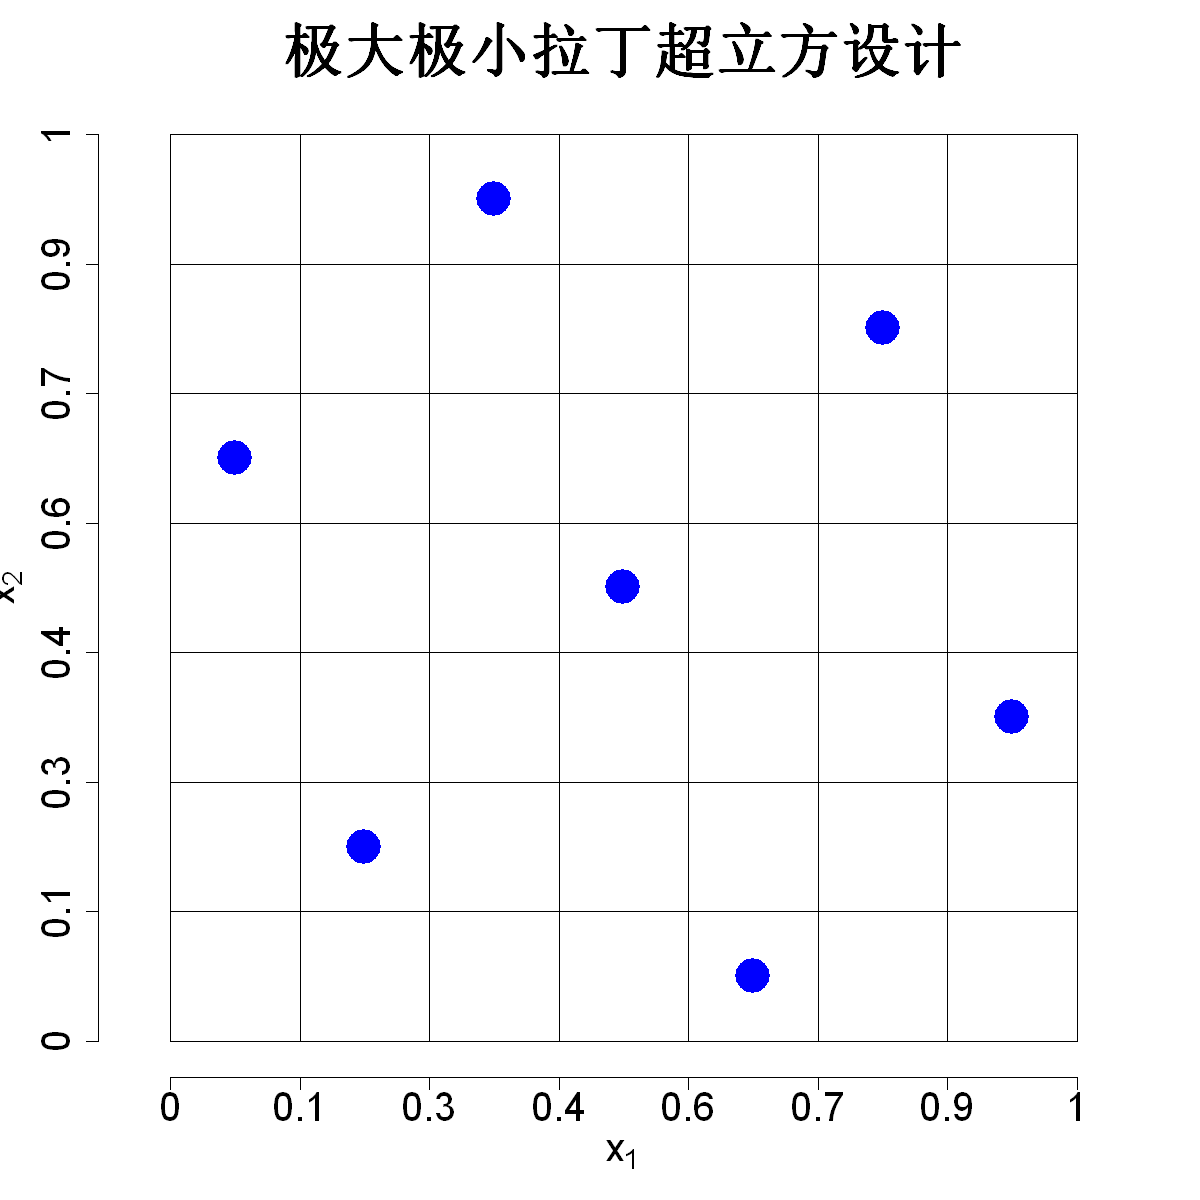

In [3]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/4.8-D.csv"))||(!file.exists("data/4.8-para.csv"))){
p=2;n=7
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
write.csv(data.frame(D=D),file="data/4.8-D.csv",row.names=FALSE)
write.csv(data.frame(n=n),file="data/4.8-para.csv",row.names=FALSE)
}
df_D=read.csv("data/4.8-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
para=read.csv("data/4.8-para.csv")
n=para$n

options(repr.plot.width=10,repr.plot.height=10)
plot(D,pch=16,cex=4,axes=FALSE,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="极大极小拉丁超立方设计",cex.main=3,asp=1)
axis(1,at=seq(0,1,by=1/7),labels=round(seq(0,1,by=1/7),1),cex.axis=2)
axis(2,at=seq(0,1,by=1/7),labels=round(seq(0,1,by=1/7),1),cex.axis=2)
for(i in 1:(n+1)){
segments(0,(i-1)/n,1,(i-1)/n)
segments((i-1)/n,0,(i-1)/n,1)
}

现有文献中已经提出多种拉丁超立方抽样（LHD）的改良方案。叶（1998）提出正交拉丁超立方抽样，该抽样方式能够让拉丁超立方抽样各列之间的相关系数为零。约瑟夫与洪（2008）将正交性与极大极小准则相结合，构造出正交极大极小拉丁超立方抽样（OMLHD）。若需要拟合均值部分为线性主效应回归模型的高斯过程（GP）模型，或是盲克里金模型，采用该抽样方案通常能取得优良效果（约瑟夫等人，2008）。可借助 R 语言 LHD 程序包中的 SA2008 函数生成正交极大极小拉丁超立方抽样样本（王等人，2022）。

上述所有拉丁超立方设计（LHD）均采用式 (4.21) 中的中心化数值，该方式可为一维投影构造极小极大设计。德特与佩佩利舍夫（2010）提出针对一维投影采用切比雪夫设计。若将该思路融合至极大极小拉丁超立方设计（MmLHD）中，可先构造一组极大极小拉丁超立方设计，再借助式 (2.5) 对数值做变换，变换形式为 $D_{ij} \leftarrow \{1+\cos(\pi D_{ij})\}/2$，其中矩阵 $D$ 代表极大极小拉丁超立方设计。图 4.9 展示了包含 20 次试验的原始极大极小拉丁超立方设计，以及经过切比雪夫变换后的极大极小拉丁超立方设计。不难发现，切比雪夫变换会将样本点向区间边界推移。该方法与式 (4.18) 中的 TRD 准则存在紧密关联。考虑一维情形，即维度 $p=1$，易证：

$$
\lim_{\alpha \to 0}
\left\{
\sum_{i=1}^{n}\sum_{j\neq i}\frac{1}{|x_i-x_j|^{2\alpha}}
\right\}^{1/\alpha}
=-2\sum_{i=1}^{n}\sum_{j\neq i}\log|x_i-x_j|
$$

等式右侧被称作对数势能。当样本量 $n$ 趋于无穷时，使对数势能准则最小化的设计服从反正弦分布，其概率密度函数为：

$$
f(x)=\frac{1}{\pi x\sqrt{1-x}}
$$

（德特、斯图登，1992）。$n$ 点切比雪夫设计能够对该密度实现最优分位数逼近。正如前文图 3.3 所示，切比雪夫设计在拟合光滑函数时表现优异，但拟合粗糙函数的效果较差。由此可见，经过切比雪夫变换得到的设计，在相关参数设定出现偏差时不具备稳健性。

> **图 4.9** 左侧图像展示了经过 20 次运算的最大最小拉丁超立方抽样（MmLHD），右侧图像则是该最大最小拉丁超立方抽样经切比雪夫变换后的结果。

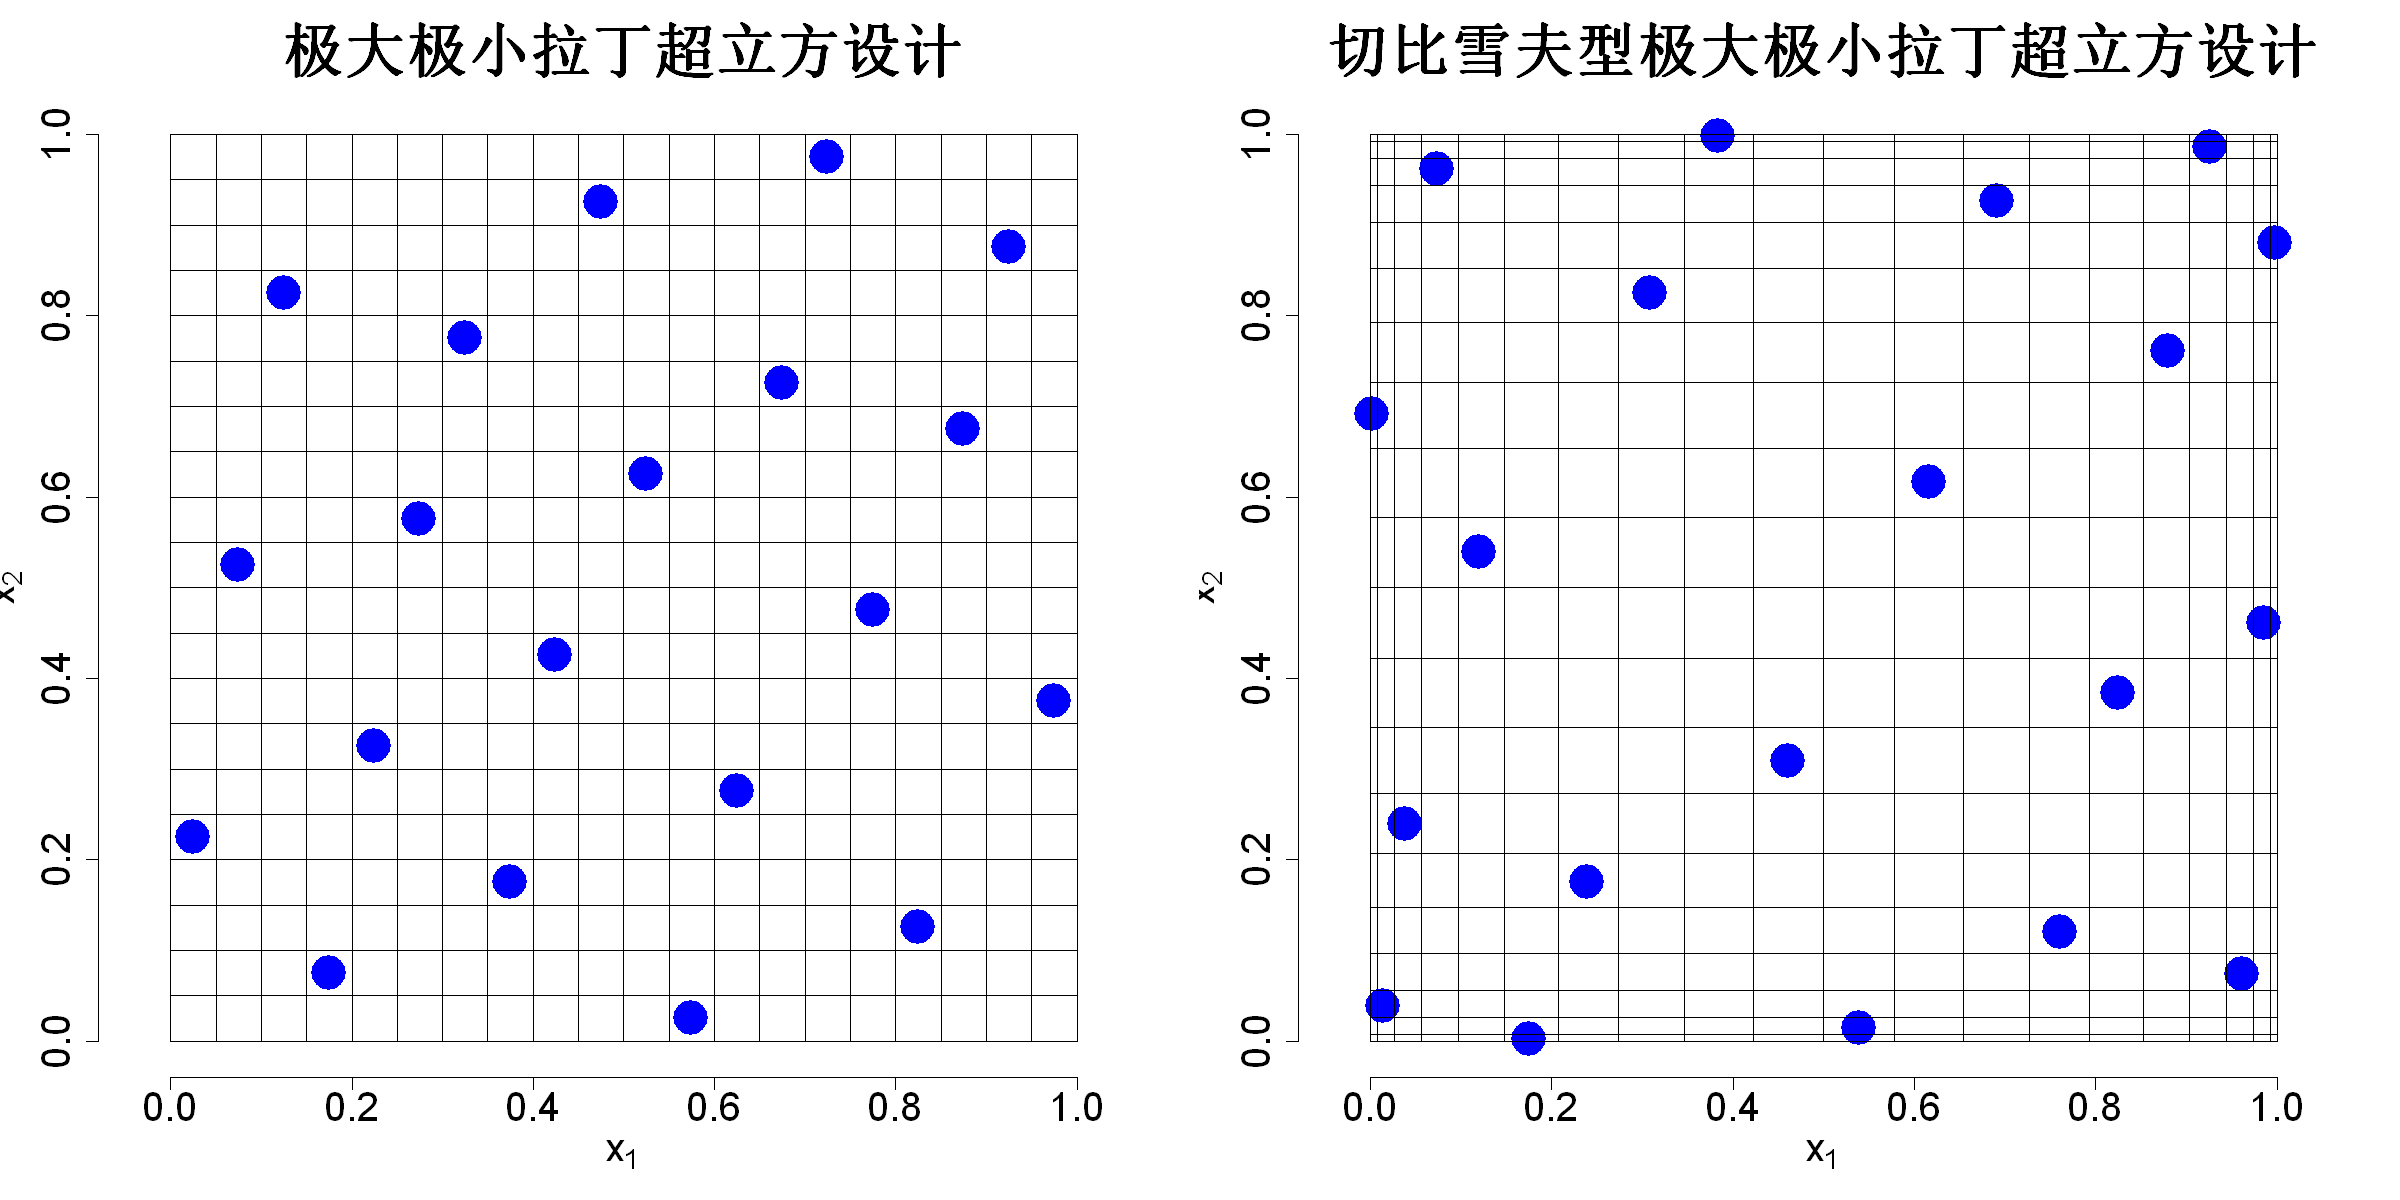

In [4]:
if(!dir.exists("data"))dir.create("data")
if((!file.exists("data/4.9-D.csv"))||(!file.exists("data/4.9-para.csv"))){
  p=2;n=20
  set.seed(1)
  library(SFDesign)
  D1=maximinLHD(n,p)$design # 20x2
  D2=(1+cos(pi*D1))/2 # 20x2
  write.csv(data.frame(D1=D1,D2=D2),"data/4.9-D.csv",row.names=FALSE)
  write.csv(data.frame(n=n),"data/4.9-para.csv",row.names=FALSE)
}

df_D=read.csv("data/4.9-D.csv")
D1=as.matrix(df_D[,paste0("D1.",1:2)])
D2=as.matrix(df_D[,paste0("D2.",1:2)])
para=read.csv("data/4.9-para.csv")
n=para$n

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="极大极小拉丁超立方设计",cex.lab=2,cex.axis=2,cex.main=3,asp=1)
for(i in 1:(n+1)){
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
plot(D2,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="切比雪夫型极大极小拉丁超立方设计",cex.main=3,asp=1)
d1=sort(D2[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D2[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1)){
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}